<a href="https://colab.research.google.com/github/mahak-025/Mood-classification/blob/main/imagerecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
!nvidia-smi


Fri Sep 25 14:23:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             28W /   70W |    1151MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [70]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
#image data generator is the pckg to lable the images & it will automatically lable all the image


In [71]:
img = image.load_img('/content/drive/MyDrive/Colab Notebooks/CNN/training/Happy/10.jpg',target_size=(200,200))

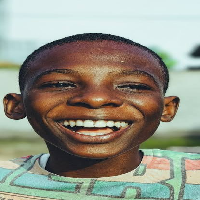

In [72]:
img

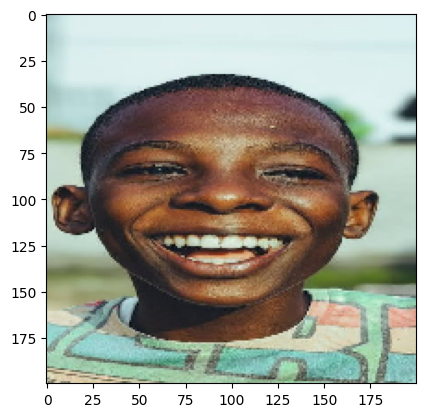

In [73]:
plt.imshow(img)


array([[[179, 183, 148],
        [181, 185, 150],
        [183, 186, 154],
        ...,
        [240, 239, 219],
        [240, 239, 219],
        [240, 239, 219]],

       [[180, 184, 149],
        [181, 185, 150],
        [184, 187, 155],
        ...,
        [240, 239, 219],
        [240, 239, 219],
        [240, 239, 219]],

       [[181, 185, 150],
        [183, 187, 152],
        [185, 188, 156],
        ...,
        [240, 239, 219],
        [240, 239, 219],
        [240, 239, 219]],

       ...,

       [[176, 202, 202],
        [194, 220, 220],
        [151, 175, 175],
        ...,
        [189, 192, 146],
        [203, 206, 160],
        [210, 213, 167]],

       [[151, 179, 180],
        [178, 203, 205],
        [113, 137, 137],
        ...,
        [213, 216, 170],
        [217, 220, 174],
        [212, 215, 169]],

       [[175, 205, 210],
        [151, 180, 184],
        [ 96, 120, 120],
        ...,
        [183, 186, 140],
        [181, 184, 138],
        [182, 184, 138]]], dtype=uint8)
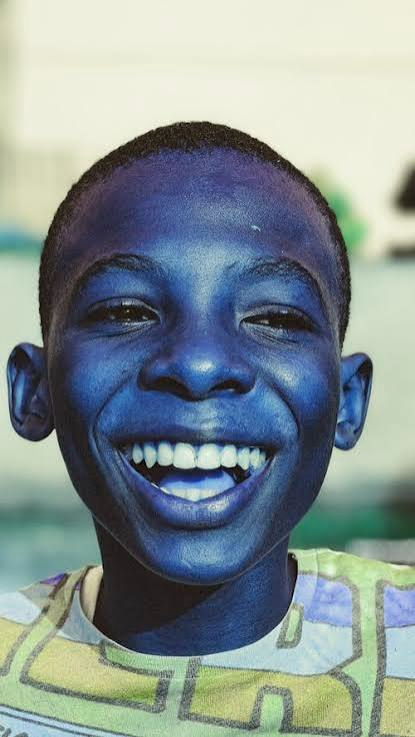

In [74]:
i1 = cv2.imread('/content/drive/MyDrive/Colab Notebooks/CNN/training/Happy/10.jpg')
i1

In [75]:
i1.shape

(737, 415, 3)

In [76]:
train = ImageDataGenerator(rescale=1/200)
validation = ImageDataGenerator(rescale=1/200)

In [77]:
train_dataset = train.flow_from_directory("/content/drive/MyDrive/Colab Notebooks/CNN/training",
                                          target_size=(200,200),
                                          batch_size=32,
                                          class_mode= 'binary')
validation_dataset = train.flow_from_directory("/content/drive/MyDrive/Colab Notebooks/CNN/validation",
                                          target_size=(200,200),
                                          batch_size=32,
                                          class_mode= 'binary')

Found 40 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [78]:
train_dataset.class_indices

{'Happy': 0, 'sad': 1}

In [79]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [80]:
model = tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3), activation ='relu',input_shape = (200,200,3)),
              tf.keras.layers.MaxPool2D(2,2),
              #
                tf.keras.layers.Conv2D(32,(3,3), activation='relu'),
                  tf.keras.layers.MaxPool2D(2,2),
              ##
                tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
                  tf.keras.layers.MaxPool2D(2,2),
              #
                  tf.keras.layers.Flatten(),
              #
                  tf.keras.layers.Dense(512, activation='relu'),
              #
                  tf.keras.layers.Dense(1, activation='sigmoid')
                                    ]
                                   )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [82]:
model_fit = model.fit(train_dataset,epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3500 - loss: 22.8237
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5500 - loss: 0.8480 
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4250 - loss: 0.7083 
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5750 - loss: 0.9830 
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4750 - loss: 0.7731
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5250 - loss: 0.6650
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.5000 - loss: 0.7096
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 0.5695 
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6000 - loss: 0.6679 
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7500 - loss: 0.5836
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8500 - loss: 0.5021
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7500 - loss

In [83]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,717,764 (132.44 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,358,883 (66.22 MB)

In [84]:
dir_path = '/content/drive/MyDrive/Colab Notebooks/CNN/testing'
for i in os.listdir(dir_path):
  print(i)

7.jpg
-2.jpg
-4.jpg
4.jpg
13.jpg
mahakphoto.jpg.png


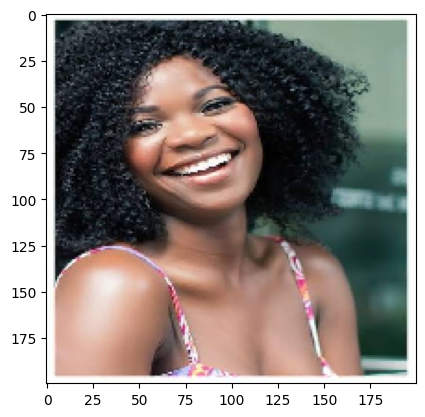

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
I am Happy!


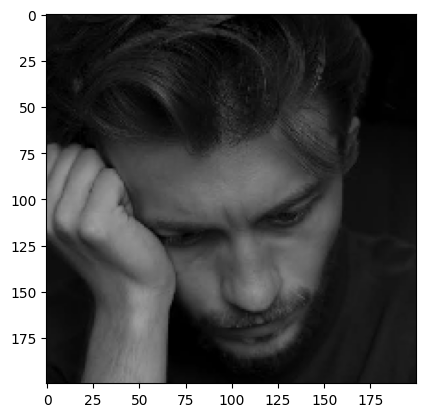

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
I am Sad!


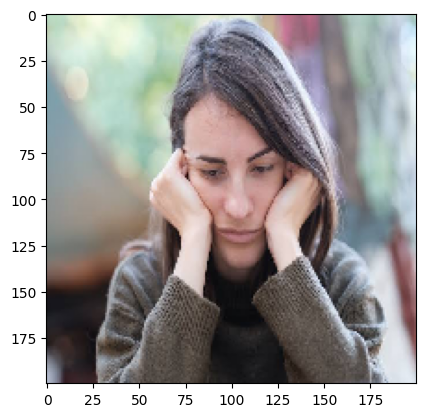

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
I am Sad!


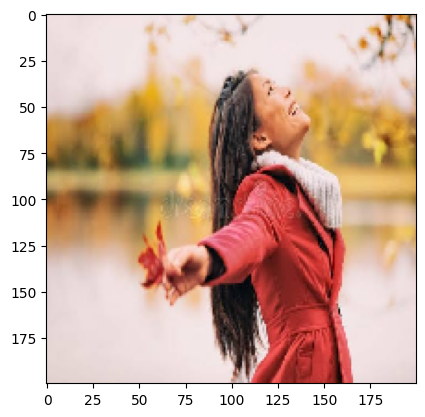

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
I am Sad!


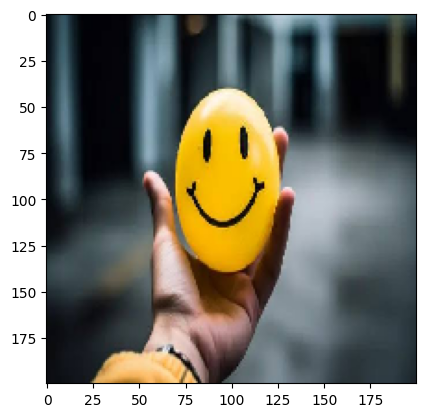

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
I am Happy!


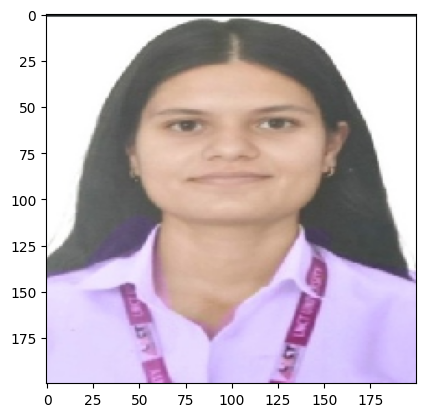

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
I am Sad!


In [85]:
dir_path = '/content/drive/MyDrive/Colab Notebooks/CNN/testing'
for i in os.listdir(dir_path):
  img = image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

  x= image.img_to_array(img)
  x= np.expand_dims(x, axis=0)
  images = np.vstack([x])

  val = model.predict(images)
  if val==0:
    print('I am Happy!')
  else:
    print('I am Sad!')


In [86]:
model.save('/content/drive/MyDrive/Colab Notebooks/CNN/mood_model.h5')

In [88]:
# Training images pe hi directly test karo (jo tumne pehle 'testing' folder wale code se kiya tha)
dir_path = '/content/drive/MyDrive/Colab Notebooks/CNN/training/sad'
import os
for i in os.listdir(dir_path)[:3]:  # sirf 3 images test karo
    img = image.load_img(dir_path + '/' + i, target_size=(200,200))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    images = np.vstack([x])
    val = model.predict(images)
    print(i, "→", val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
-1.jpg → [[1.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
-2.jpg → [[1.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
-3.jpg → [[1.]]


In [89]:
!pip install gradio -q

import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image

# ---------------- LOAD MODEL ----------------
model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/CNN/mood_model.h5')

# ---------------- PREDICTION FUNCTION ----------------
def predict_mood(img):
    img = img.convert("RGB")  # RGBA → RGB conversion rakhna hai (webcam ke liye zaroori)
    img = img.resize((200, 200))
    x = image.img_to_array(img)  # /255.0 hata diya — training mein rescaling nahi thi
    x = np.expand_dims(x, axis=0)
    images = np.vstack([x])

    val = model.predict(images)[0][0]
    print("Raw prediction value:", val)

    if val < 0.5:
        label = "😊 Happy"
        confidence = (1 - val) * 100
    else:
        label = "😢 Sad"
        confidence = val * 100

    return f"{label}  ({confidence:.1f}% confidence)"
# ---------------- CUSTOM THEME ----------------
custom_theme = gr.themes.Soft(
    primary_hue="purple",
    secondary_hue="pink",
).set(
    button_primary_background_fill="*primary_500",
    button_primary_background_fill_hover="*primary_600",
)

# ---------------- INTERFACE ----------------
with gr.Blocks(theme=custom_theme, title="Mood Classification") as demo:
    gr.Markdown(
        """
        <div style="text-align: center;">
            <h1>🎭 Mood Classification</h1>
            <p style="font-size: 16px; color: gray;">
                Upload a face image or use your webcam, and let the AI detect whether the mood is Happy or Sad!
            </p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(
                type="pil",
                label="Upload Image or Use Camera",
                height=350,
                sources=["upload", "webcam"]
            )
            predict_btn = gr.Button("🔍 Predict Mood", variant="primary", size="lg")

        with gr.Column(scale=1):
            output_label = gr.Textbox(
                label="Prediction Result",
                placeholder="Result will appear here after prediction...",
                lines=2,
                interactive=False
            )

    predict_btn.click(fn=predict_mood, inputs=img_input, outputs=output_label)

    gr.Markdown(
        """
        <div style="text-align: center; margin-top: 20px; color: gray; font-size: 13px;">
            Built with a CNN trained on happy/sad facial expressions.
        </div>
        """
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_1152/1794989748.py:41: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=custom_theme, title="Mood Classification") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d6aee8c0876b1c7b0b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
Raw prediction value: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Raw prediction value: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Raw prediction value: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Raw prediction value: 1.0
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d6aee8c0876b1c7b0b.gradio.live
